In [1]:
# # KGQA Expert Evaluation Analysis (Refactored)
#
# This notebook analyzes expert evaluations from CSV files.
# The refactoring focuses on:
# 1.  **Efficiency and Readability**: Replacing manual loops with idiomatic pandas functions.
# 2.  **Modularity and Reusability**: Encapsulating repetitive analysis and plotting logic into functions.
# 3.  **Clarity**: Adding comments and using clear variable names.

# %%
# ==============================================================================
# 1. SETUP AND IMPORTS
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import os

# --- Configuration ---
# Load constants from an external JSON file
# Ensure the path is correct for your environment
PATH_TO_CONSTANTS = "../"
CONSTANTS_PATH = os.path.join(PATH_TO_CONSTANTS, "constants.json")

try:
    with open(CONSTANTS_PATH) as f:
        CONSTANTS = json.load(f)
    FIGURES_DIR = os.path.join(PATH_TO_CONSTANTS, CONSTANTS.get('figures', 'figures/'))
    LLM_OUTS_DIR = os.path.join(PATH_TO_CONSTANTS, CONSTANTS.get('llm_outs', 'llm_outs/'))
    os.makedirs(FIGURES_DIR, exist_ok=True) # Ensure figure directory exists
except FileNotFoundError:
    print(f"Warning: '{CONSTANTS_PATH}' not found. Using default paths.")
    FIGURES_DIR = "figures/"
    LLM_OUTS_DIR = "llm_outs/"
    os.makedirs(FIGURES_DIR, exist_ok=True)


In [2]:


# %%
# ==============================================================================
# 2. DATA LOADING AND NORMALIZATION
# ==============================================================================
def load_and_normalize_data(file_paths):
    """
    Reads multiple CSV files, concatenates them, and normalizes the structure.

    This function replaces the original while-loop with efficient, vectorized
    pandas operations.
    """
    # Define column names for clarity
    col_names = ["ID", "Question", "Answer", "Evaluation Category", "Score"]

    # Read and concatenate all files
    df_list = [pd.read_csv(file,
 header=None, names=col_names) for file in file_paths]
    df = pd.concat(df_list, ignore_index=True).iloc[1:] # Skip header row from original files

    # --- Idiomatic Pandas Normalization ---
    # Forward-fill the ID, Question, and Answer to associated rows
    fill_cols = ["ID", "Question", "Answer"]
    df[fill_cols] = df[fill_cols].ffill()

    # Drop rows that don't have an evaluation category or score
    df.dropna(subset=["Evaluation Category", "Score"], inplace=True)

    # Clean up data types and whitespace
    df["ID"] = pd.to_numeric(df["ID"], errors='coerce').astype('Int64')
    df["Evaluation Category"] = df["Evaluation Category"].str.strip()
    df["Score"] = df["Score"].str.strip()

    return df

# --- Execution ---
files_to_load = [
    "KGQA expert evaluation - Evaluation.csv",
    "KGQA expert evaluation - Evaluation P2.csv"
]
normalized_df = load_and_normalize_data(files_to_load)

print("Data loaded and normalized successfully.")
display(normalized_df.head())



Data loaded and normalized successfully.


,ID,Question,Answer,Evaluation Category,Score
1,118419,"Considering the network of pegylated drugs, ho...","Through its connection to Pegfilgrastim, a G-C...",Scientific Validity of the Question,5. Completely valid: Perfectly aligned with cu...
2,118419,"Considering the network of pegylated drugs, ho...","Through its connection to Pegfilgrastim, a G-C...",Scientific Validity of the Answer,2. Slightly valid: Major scientific inaccuraci...
3,118419,"Considering the network of pegylated drugs, ho...","Through its connection to Pegfilgrastim, a G-C...",Question Complexity,5. Very complex: Question requiring synthesis ...
4,118419,"Considering the network of pegylated drugs, ho...","Through its connection to Pegfilgrastim, a G-C...",Specificity of Answer,2. Somewhat general: Answer provides some spec...
5,118419,"Considering the network of pegylated drugs, ho...","Through its connection to Pegfilgrastim, a G-C...",Answer Completeness,3. Moderately complete: Answer covers most cri...


In [3]:

# %%
# ==============================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================
def prepare_eda_dataframe(df):
    """Prepares the DataFrame for analysis by parsing scores."""
    eda_df = df.drop(columns=["Question", "Answer"]).copy()

    # Extract numeric part of the score
    eda_df["Numeric Score"] = pd.to_numeric(eda_df["Score"].str.extract(r"(\d+)", expand=False), errors='coerce')

    # Categorize evaluations as "Qualified" (numeric score) or "Not Qualified"
    eda_df["Is Qualified"] = eda_df["Numeric Score"].notna()
    eda_df["Evaluation Status"] = np.where(eda_df["Is Qualified"], "Qualified", "Not Qualified")

    return eda_df

# --- Execution ---
eda_df = prepare_eda_dataframe(normalized_df)

print("EDA DataFrame prepared. Evaluation status counts:")
print(eda_df["Evaluation Status"].value_counts())

print("\nSummary statistics for qualified evaluations:")
qualified_df = eda_df[eda_df["Is Qualified"]].copy()
summary_stats = qualified_df.groupby("Evaluation Category")["Numeric Score"].describe()
print(summary_stats)



EDA DataFrame prepared. Evaluation status counts:
Evaluation Status
Qualified        530
Not Qualified     13
Name: count, dtype: int64

Summary statistics for qualified evaluations:
                                     count      mean       std  min   25%  \
Evaluation Category                                                         
Answer Completeness                  106.0  4.103774  1.186666  1.0  3.00   
Question Complexity                  106.0  3.377358  0.761613  2.0  3.00   
Scientific Validity of the Answer    106.0  3.764151  1.199618  1.0  3.00   
Scientific Validity of the Question  106.0  4.952830  0.253812  3.0  5.00   
Specificity of Answer                106.0  3.150943  0.923683  1.0  2.25   

                                     50%  75%  max  
Evaluation Category                                 
Answer Completeness                  5.0  5.0  5.0  
Question Complexity                  3.0  4.0  5.0  
Scientific Validity of the Answer    4.0  5.0  5.0  
Scientific V

In [8]:
# %%
# ==============================================================================
# 5. ANALYSIS OF SCORES AND THRESHOLDS
# ==============================================================================

# --- Calculate percentage of scores above thresholds (All Answers) ---
thresholds = [2, 3, 4]
percentage_results = qualified_df.groupby("Evaluation Category")["Numeric Score"].apply(
    lambda s: pd.Series({f">= {t}": (s >= t).mean() * 100 for t in thresholds})
).unstack().round(2)

print("Percentage of Scores Above Thresholds by Category (All Answers):")
print(percentage_results)


# --- Load external accepted/rejected datasets to get the IDs ---
# This part is needed first to know which IDs are 'accepted'
def load_ids_from_jsonl(filepath):
    """Loads a set of IDs from a .jsonl file."""
    try:
        with open(filepath, "r") as f:
            return {json.loads(line)['id'] for line in f}
    except FileNotFoundError:
        print(f"Warning: File not found at {filepath}")
        return set()

rejected_ids = load_ids_from_jsonl(os.path.join(LLM_OUTS_DIR, "FILTER_DATASET/rejected_ds.jsonl"))
# To be safe, we get accepted_ids from qualified_df to ensure we are only working with evaluated data
all_evaluated_ids = qualified_df['ID'].unique()
accepted_ids = [id for id in all_evaluated_ids if id not in rejected_ids]


# --- NEW: Calculate percentage of scores above thresholds (Accepted Answers Only) ---
# 1. Filter the main qualified_df to only include accepted IDs
accepted_qualified_df = qualified_df[qualified_df['ID'].isin(accepted_ids)]

# 2. Run the same calculation on the filtered DataFrame
accepted_percentage_results = accepted_qualified_df.groupby("Evaluation Category")["Numeric Score"].apply(
    lambda s: pd.Series({f">= {t}": (s >= t).mean() * 100 for t in thresholds})
).unstack().round(2)

print("\nPercentage of Scores Above Thresholds by Category (Accepted Answers Only):")
print(accepted_percentage_results)


# --- Calculate average and minimum scores per ID ---
# Exclude subjective question-related categories from answer evaluation
filtered_qualified = qualified_df[
    ~qualified_df["Evaluation Category"].isin([
        "Scientific Validity of the Question", "Question Complexity"
    ])
]

id_scores_df = filtered_qualified.groupby("ID")["Numeric Score"].agg(['mean', 'min']).rename(
    columns={'mean': 'Avg Score', 'min': 'Min Score'}
).reset_index()


# --- Reusable function for printing statistics ---
def print_score_stats(df, score_col, label):
    """Calculates and prints a standard set of statistics for a score column."""
    if df.empty:
        print(f"No data for '{label}'")
        return
    print(f"\n--- Statistics for: {label} ({score_col}) ---")
    print(f"Overall average score: {df[score_col].mean():.2f}")
    print(f"Overall minimum score: {df[score_col].min():.2f}")
    count_above_2_5 = (df[score_col] > 2.5).sum()
    percentage_above_2_5 = (count_above_2_5 / len(df)) * 100
    print(f"Count of IDs with score > 2.5: {count_above_2_5} / {len(df)} ({percentage_above_2_5:.2f}%)")
    count_above_3_5 = (df[score_col] > 3.5).sum()
    percentage_above_3_5 = (count_above_3_5 / len(df)) * 100
    print(f"Count of IDs with score > 3.5: {count_above_3_5} / {len(df)} ({percentage_above_3_5:.2f}%)")


# --- Execution of statistical analysis ---
rejected_scores_df = id_scores_df[id_scores_df["ID"].isin(rejected_ids)]
accepted_scores_df = id_scores_df[id_scores_df["ID"].isin(accepted_ids)]

print_score_stats(id_scores_df, "Avg Score", "All Answers")
print_score_stats(id_scores_df, "Min Score", "All Answers")
print_score_stats(accepted_scores_df, "Min Score", "Accepted Answers")
print_score_stats(accepted_scores_df, "Avg Score", "Accepted Answers")

print_score_stats(rejected_scores_df, "Min Score", "Rejected Answers")

Percentage of Scores Above Thresholds by Category (All Answers):
                                       >= 2    >= 3   >= 4
Evaluation Category                                       
Answer Completeness                   96.23   89.62  66.98
Question Complexity                  100.00   88.68  43.40
Scientific Validity of the Answer     97.17   82.08  58.49
Scientific Validity of the Question  100.00  100.00  99.06
Specificity of Answer                 98.11   74.53  35.85

Percentage of Scores Above Thresholds by Category (Accepted Answers Only):
                                       >= 2    >= 3    >= 4
Evaluation Category                                        
Answer Completeness                   98.72   93.59   79.49
Question Complexity                  100.00   88.46   43.59
Scientific Validity of the Answer    100.00   92.31   67.95
Scientific Validity of the Question  100.00  100.00  100.00
Specificity of Answer                 97.44   79.49   42.31

--- Statistics for: All A

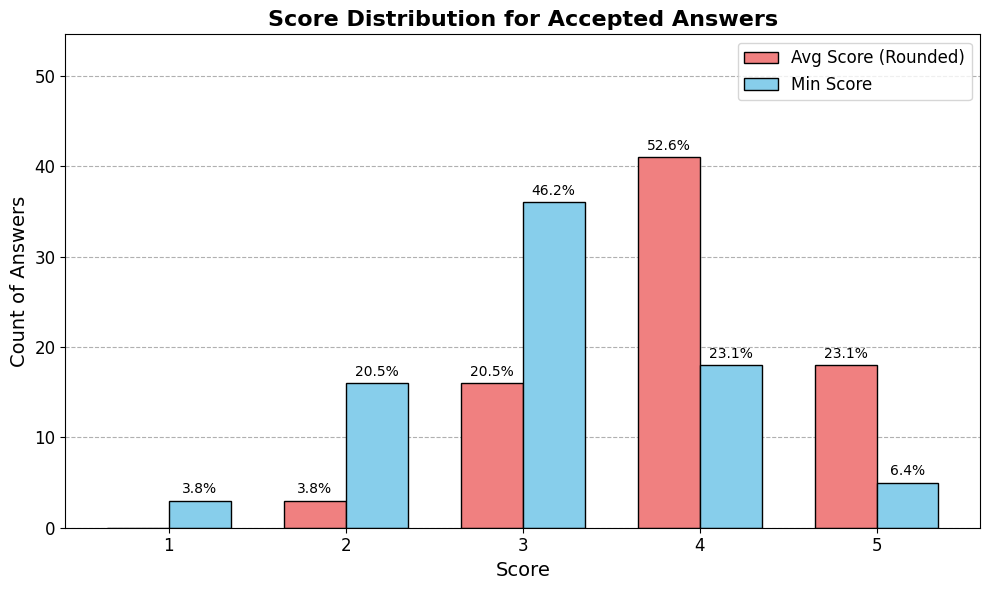

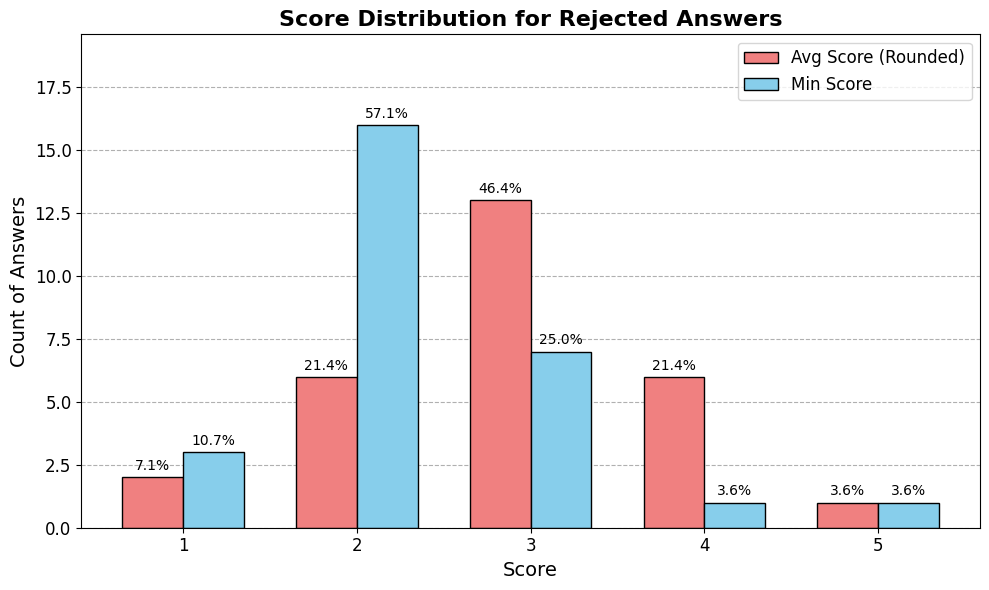

In [6]:


# %%
# ==============================================================================
# 6. DISTRIBUTION PLOTS FOR ACCEPTED VS. REJECTED
# ==============================================================================

def plot_answer_score_distribution(scores_df, title, save_filename, ylim):
    """
    Creates and saves a bar chart showing the distribution of Min and Avg scores.
    """
    if scores_df.empty:
        print(f"Skipping plot '{title}' due to no data.")
        return

    bin_labels = [1, 2, 3, 4, 5]
    min_counts = scores_df["Min Score"].value_counts().reindex(bin_labels, fill_value=0)
    avg_counts = scores_df["Avg Score"].round().astype(int).value_counts().reindex(bin_labels, fill_value=0)

    x = np.arange(len(bin_labels))
    bar_width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars_avg = ax.bar(x - bar_width/2, avg_counts, bar_width, label='Avg Score (Rounded)', color='lightcoral', edgecolor='black', zorder=2)
    bars_min = ax.bar(x + bar_width/2, min_counts, bar_width, label='Min Score', color='skyblue', edgecolor='black', zorder=2)

    # Add percentage labels
    for bars, total in [(bars_avg, avg_counts.sum()), (bars_min, min_counts.sum())]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.annotate(f'{(height/total)*100:.1f}%',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3), textcoords="offset points",
                            ha='center', va='bottom', fontsize=10)

    # Aesthetics
    ax.set_xlabel("Score", fontsize=14)
    ax.set_ylabel("Count of Answers", fontsize=14)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xticks(x, bin_labels)
    ax.set_ylim(0, ylim)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12)
    ax.grid(True, axis='y', linestyle='--', zorder=0)

    plt.tight_layout()
    save_path = os.path.join(FIGURES_DIR, save_filename)
    plt.savefig(save_path, format='pdf', dpi=300)
    plt.show()

# --- Execution ---
plot_answer_score_distribution(
    accepted_scores_df,
    "Score Distribution for Accepted Answers",
    "Score_Distribution_accepted_answer.pdf",
    ylim=max(accepted_scores_df.shape[0] * 0.7, 10) # Dynamic ylim
)

plot_answer_score_distribution(
    rejected_scores_df,
    "Score Distribution for Rejected Answers",
    "Score_Distribution_rejected_answer.pdf",
    ylim=max(rejected_scores_df.shape[0] * 0.7, 10) # Dynamic ylim
)


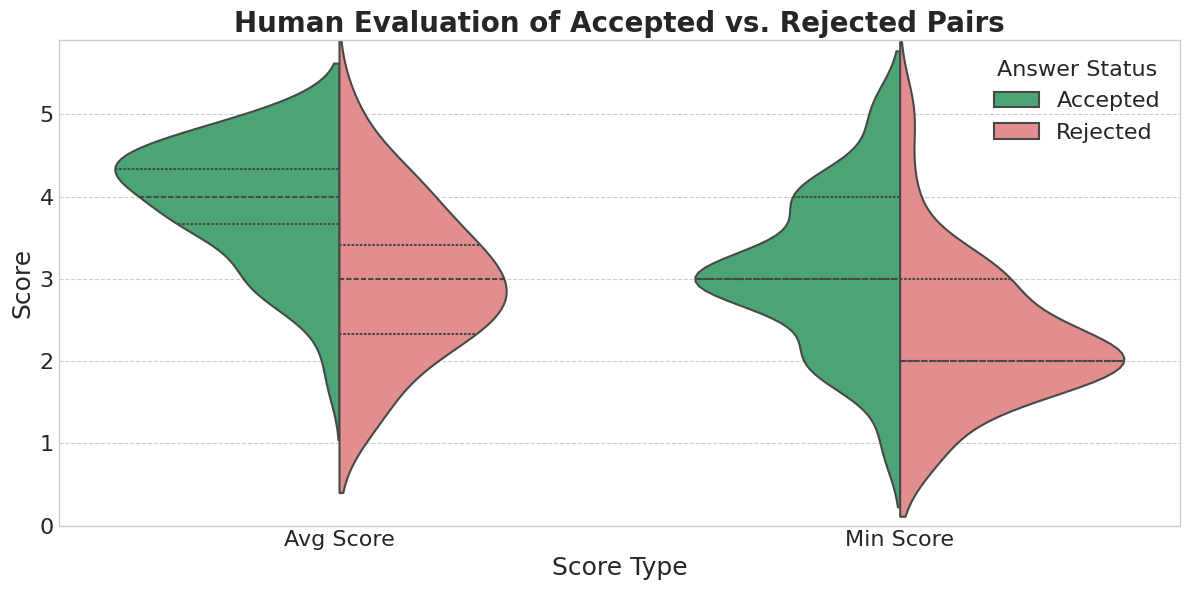

In [7]:
# ==============================================================================
# 6. ASYMMETRIC (SPLIT) VIOLIN PLOT FOR ACCEPTED VS. REJECTED (PUBLICATION STYLE)
# ==============================================================================

def plot_split_violin_comparison(accepted_df, rejected_df, title, save_filename):
    """
    Creates a split violin plot to directly compare the score distributions
    of accepted and rejected answers, styled for publication.
    """
    # --- 1. Combine Data ---
    accepted_df['Status'] = 'Accepted'
    rejected_df['Status'] = 'Rejected'
    combined_df = pd.concat([accepted_df, rejected_df], ignore_index=True)

    if combined_df.empty:
        print(f"Skipping plot '{title}' due to no data.")
        return

    # --- 2. Reshape Data ---
    melted_df = pd.melt(combined_df,
                        id_vars=['ID', 'Status'],
                        value_vars=['Avg Score', 'Min Score'],
                        var_name='Score Type',
                        value_name='Score')

    # --- 3. Create the Plot ---
    plt.style.use('seaborn-v0_8-whitegrid')
    # <<< FIGURE SIZE ADJUSTED FOR BETTER ASPECT RATIO >>>
    fig, ax = plt.subplots(figsize=(12, 6))

    sns.violinplot(
        data=melted_df,
        x='Score Type',
        y='Score',
        hue='Status',
        split=True,
        palette={'Accepted': 'mediumseagreen', 'Rejected': 'lightcoral'},
        inner='quart',
        # <<< BOLDER LINES >>>
        linewidth=1.5,
        ax=ax
    )

    # --- Aesthetics and Labels (with Larger Fonts) ---
    # <<< FONT SIZES INCREASED >>>
    ax.set_title(title, fontsize=20, fontweight='bold')
    ax.set_xlabel("Score Type", fontsize=18)
    ax.set_ylabel("Score", fontsize=18)
    ax.set_ylim(0, 5.9)
    ax.tick_params(axis='both', labelsize=16)
    ax.grid(True, axis='y', linestyle='--', zorder=0)

    # Improve legend with larger fonts
    handles, labels = ax.get_legend_handles_labels()
    legend = ax.legend(handles, ['Accepted', 'Rejected'], title='Answer Status', fontsize=16)
    plt.setp(legend.get_title(), fontsize='16')

    plt.tight_layout()

    # --- Save and Show ---
    save_path = os.path.join(FIGURES_DIR, save_filename)
    # <<< ADDED bbox_inches='tight' FOR BETTER SAVING >>>
    plt.savefig(save_path+".pdf", format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(save_path+".png", format='png', dpi=300, bbox_inches='tight')

    plt.show()

# --- Execution ---
# Call the function with the original accepted and rejected dataframes
plot_split_violin_comparison(
    accepted_scores_df.copy(), # Use .copy() to avoid SettingWithCopyWarning
    rejected_scores_df.copy(),
    "Human Evaluation of Accepted vs. Rejected Pairs", # Shortened title for aesthetics
    "Score_Split_Violin_Comparison"
)

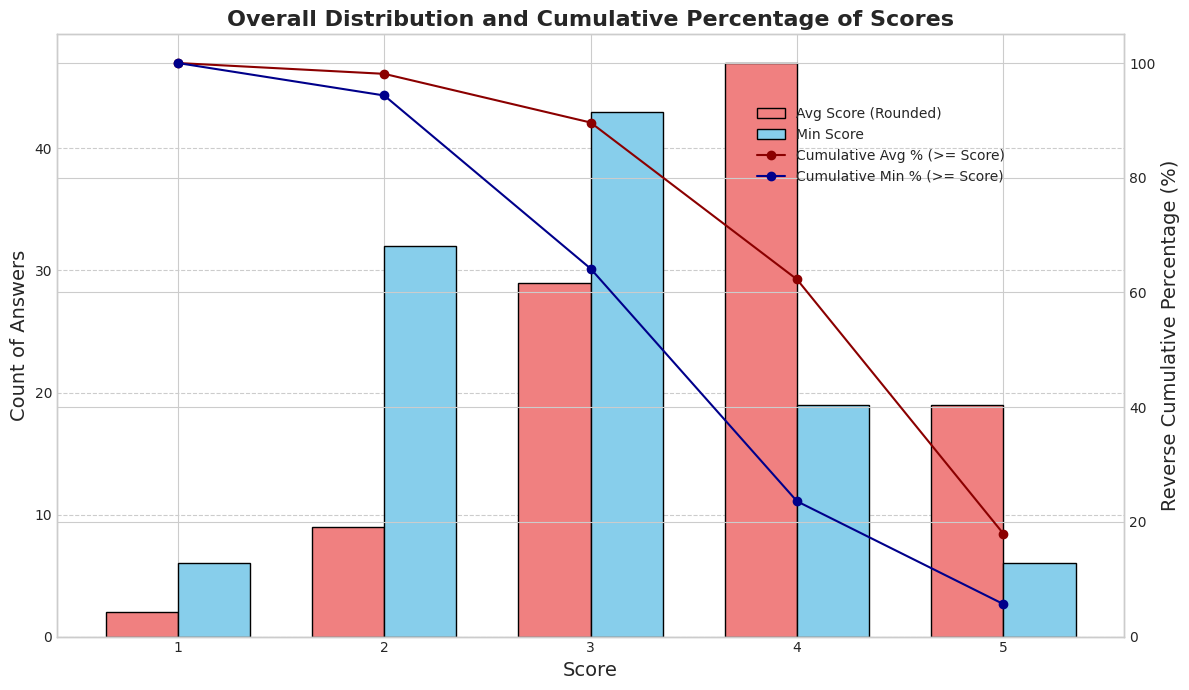

In [8]:


# %%
# ==============================================================================
# 7. OVERALL DISTRIBUTION WITH CUMULATIVE PERCENTAGE
# ==============================================================================
def plot_overall_distribution_and_cumulative(scores_df, title, save_filename):
    """
    Creates a combined bar and line chart for score distribution and reverse
    cumulative percentage.
    """
    bin_labels = [1, 2, 3, 4, 5]
    min_counts = scores_df["Min Score"].value_counts().reindex(bin_labels, fill_value=0).sort_index()
    avg_counts = scores_df["Avg Score"].round().astype(int).value_counts().reindex(bin_labels, fill_value=0).sort_index()

    # Calculate reverse cumulative percentage P(score >= bin)
    inv_cum_min_pct = min_counts.iloc[::-1].cumsum().iloc[::-1] / min_counts.sum() * 100
    inv_cum_avg_pct = avg_counts.iloc[::-1].cumsum().iloc[::-1] / avg_counts.sum() * 100

    x = np.arange(len(bin_labels))
    bar_width = 0.35

    # Plotting
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Bar chart (Primary Y-axis)
    ax1.bar(x - bar_width/2, avg_counts, bar_width, label='Avg Score (Rounded)', color='lightcoral', edgecolor='black', zorder=2)
    ax1.bar(x + bar_width/2, min_counts, bar_width, label='Min Score', color='skyblue', edgecolor='black', zorder=2)
    ax1.set_xlabel("Score", fontsize=14)
    ax1.set_ylabel("Count of Answers", fontsize=14)
    ax1.set_xticks(x, bin_labels)

    # Line chart (Secondary Y-axis)
    ax2 = ax1.twinx()
    ax2.plot(x, inv_cum_avg_pct, 'o-', color='darkred', label='Cumulative Avg % (>= Score)', zorder=3)
    ax2.plot(x, inv_cum_min_pct, 'o-', color='darkblue', label='Cumulative Min % (>= Score)', zorder=3)
    ax2.set_ylabel("Reverse Cumulative Percentage (%)", fontsize=14)
    ax2.set_ylim(0, 105)

    # Aesthetics and Legends
    ax1.set_title(title, fontsize=16, fontweight='bold')
    fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9), bbox_transform=ax1.transAxes)
    ax1.grid(True, axis='y', linestyle='--', zorder=0)

    plt.tight_layout()
    save_path = os.path.join(FIGURES_DIR, save_filename)
    plt.savefig(save_path, format='png', dpi=300)
    plt.show()

# --- Execution ---
plot_overall_distribution_and_cumulative(
    id_scores_df,
    "Overall Distribution and Cumulative Percentage of Scores",
    "Score_Distribution_overall_answer.png"
)

/tmp/ipykernel_35122/662720371.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_35122/662720371.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(wrapped_categories, rotation=20, ha='right')


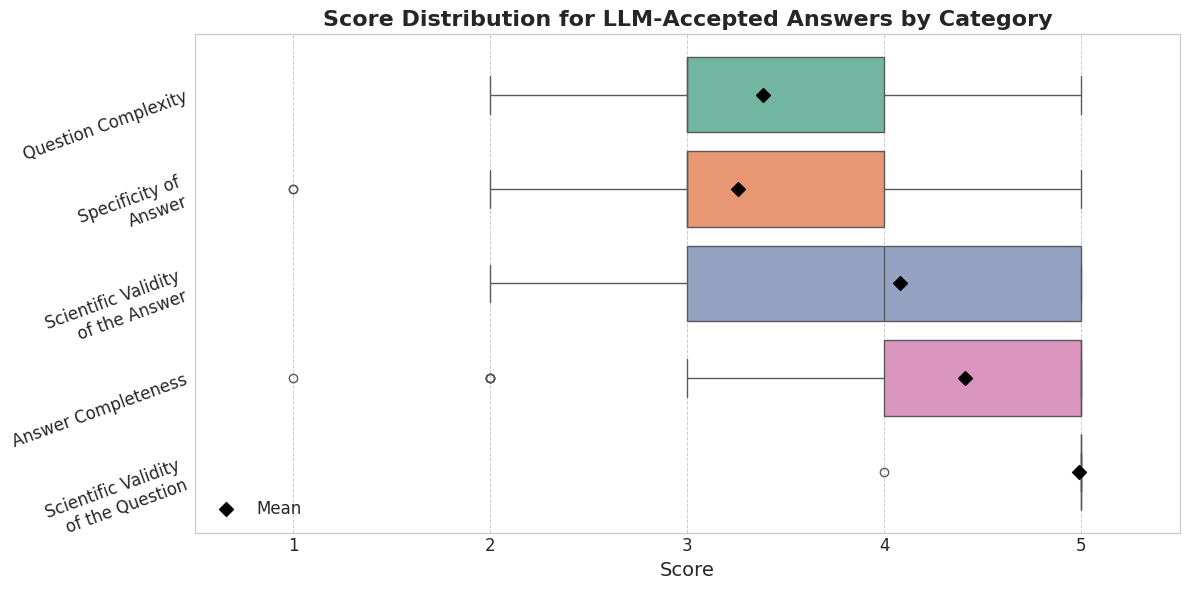

In [10]:
# %%
# ==============================================================================
# 4. VISUALIZATION (FOR ACCEPTED ANSWERS ONLY)
# ==============================================================================

# --- Helper function for wrapping long labels (unchanged) ---
def wrap_label(label, max_width=19):
    """Wraps text for plot labels to prevent overlap."""
    # This function remains the same as before.
    words = label.split()
    wrapped_label = ''
    current_line = ''
    for word in words:
        if len(current_line) + len(word) + 1 <= max_width:
            current_line += f' {word}' if current_line else word
        else:
            wrapped_label += f'\n{current_line}' if wrapped_label else current_line
            current_line = word
    if current_line:
        wrapped_label += f'\n{current_line}' if wrapped_label else current_line
    return wrapped_label

# --- Boxplot of Score Distribution (Modified for Reusability) ---
def plot_score_distribution_by_category(df, title, save_filename):
    """
    Creates and saves a detailed boxplot of scores by category.
    Now accepts a title and filename to make it reusable.
    """
    # Check if the dataframe is empty to avoid errors
    if df.empty:
        print(f"Skipping plot '{title}' because the DataFrame is empty.")
        return

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 6))

    # Order categories by median score for better readability
    ordered_categories = (
        df.groupby("Evaluation Category")["Numeric Score"]
        .median()
        .sort_values()
        .index
    )
    wrapped_categories = [wrap_label(cat) for cat in ordered_categories]

    sns.boxplot(
        data=df, x="Numeric Score", y="Evaluation Category",
        order=ordered_categories, orient='h', palette="Set2", ax=ax
    )

    # Overlay mean markers
    means = df.groupby("Evaluation Category")["Numeric Score"].mean()
    ax.scatter(means[ordered_categories], range(len(ordered_categories)),
               color='black', marker='D', s=50, zorder=3, label="Mean")

    # Aesthetics and labels (using the provided title)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel("Score", fontsize=14)
    ax.set_ylabel("")
    ax.set_yticklabels(wrapped_categories, rotation=20, ha='right')
    ax.set_xlim(0.5, 5.5)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(loc='lower left', fontsize=12)
    ax.grid(True, axis='x', linestyle='--', linewidth=0.7)

    plt.tight_layout()

    # Use the configured path and provided filename for saving
    save_path = os.path.join(FIGURES_DIR, save_filename)
    plt.savefig(save_path+".pdf", format='pdf', dpi=300)
    plt.savefig(save_path+".png", format='pdf', dpi=300)

    
    plt.show()

# --- Execution ---
# 1. Filter the qualified_df for ONLY accepted IDs
#    (assuming 'accepted_ids' is available from the previous cell)
accepted_qualified_df = qualified_df[qualified_df['ID'].isin(accepted_ids)]

# 2. Call the plotting function with the filtered data and new details
plot_score_distribution_by_category(
    df=accepted_qualified_df,
    title="Score Distribution for LLM-Accepted Answers by Category",
    save_filename="Score_Distribution_category_accepted"
)

In [11]:
len(accepted_qualified_df)

390

In [12]:
len(qualified_df)

530